In [1]:
data_link = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/LwubmHsv4Nd22Ld1_hfKGg/customer-churn-dataset.csv"
import warnings
from pprint import pprint
warnings.filterwarnings("ignore")

In [2]:
!pip install --q aix360==0.3.0 | tail -n 1
!pip install --q tensorflow==2.18.0 | tail -n 1
!pip install --q pandas==2.2.3 | tail -n 1
!pip install --q shap==0.46.0 | tail -n 1
!pip install --q --no-deps xport==3.6.1 | tail -n 1
!pip install --q cvxpy==1.5.3 | tail -n 1
!pip install --q seaborn==0.13.2 | tail -n 1
!pip install --q matplotlib==3.10.0 | tail -n 1
!pip install --q ibm-watsonx-ai==1.0.10 | tail -n 1

print("Installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 MB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.3.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.10.0 whi

In [3]:
import pandas as pd
pd.set_option('display.max_colwidth',None)
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from aix360.algorithms.ted import TED_CartesianExplainer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report, precision_score, recall_score
from pprint import pprint
print('done')

done


In [4]:
# If considering using IBM-Watson for the Gen-AI parts

# from ibm_watsonx_ai import APIClient, Credentials
# from ibm_watsonx_ai.foundation_models.inference import ModelInference
# from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams
# from ibm_watsonx_ai.foundation_models.utils.enums import DecodingMethods
# print('done')

## <a id='background'></a>[Background](#toc)

Here, we will explore how to use Explainable AI (XAI) techniques to analyse the Customer Churn Dataset. Our goal is to create a model that not only predicts customer churn but also provides interpretable explanations for its predictions. Through this exercise, we will be using `TED_CartesianExplainer`, a powerful XAI tool, to build transparent, explainable models.

Explainable AI (XAI) is critical in real-world applications where decisions impact people and businesses. By using domain-relevant explanations (TED)`, this project demonstrates how to interpret and trust model predictions effectively. Learners will gain hands-on experience in building interpretable machine learning pipelines, addressing data preprocessing challenges, and evaluating explainability outputs.

This project provides a comprehensive guide to integrating advanced explainability techniques into machine learning workflows, ensuring fair, interpretable, and actionable outcomes for business decision-making.

### Explainability framework: Insights from multiple angles

To make AI-driven insights accessible, we focus on providing explanations that cater to different facets of churn prevention analysis:

#### 1. Feature-level explanations

- Feature-level insights help Management understand the impact of specific attributes (e.g., Tenure, Payment-Delay) on employee retention.
- The **TED_CartesianExplainer** provides feature-driven explanations, enabling Finance teams to pinpoint critical factors contributing to customer churn.

#### 2. Comprehensive decision-making

- By focusing on feature-level explanations, the analysis equips decision-makers with actionable recommendations to address attrition challenges.
- Interpretability ensures that models align with business goals, offering transparency in predictive outcomes.

In the following sections, we will apply these explainability techniques to understand churn prevention, providing valuable insights for finance and management teams.


In [5]:
df = pd.read_csv(data_link)
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,71073.0,27.0,Male,14.0,28.0,3.0,16.0,Standard,Monthly,862.00,9.0,1.0
1,230192.0,40.0,Male,19.0,2.0,8.0,28.0,Standard,Monthly,620.81,21.0,1.0
2,22407.0,27.0,Female,57.0,3.0,0.0,24.0,Standard,Annual,915.00,26.0,1.0
3,290822.0,40.0,Male,21.0,14.0,0.0,11.0,Basic,Annual,592.83,9.0,0.0
4,172430.0,39.0,Male,58.0,4.0,2.0,8.0,Standard,Monthly,694.00,15.0,1.0


In [6]:
df.shape

(10000, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         10000 non-null  float64
 1   Age                10000 non-null  float64
 2   Gender             10000 non-null  object 
 3   Tenure             10000 non-null  float64
 4   Usage Frequency    10000 non-null  float64
 5   Support Calls      10000 non-null  float64
 6   Payment Delay      10000 non-null  float64
 7   Subscription Type  10000 non-null  object 
 8   Contract Length    10000 non-null  object 
 9   Total Spend        10000 non-null  float64
 10  Last Interaction   10000 non-null  float64
 11  Churn              10000 non-null  float64
dtypes: float64(9), object(3)
memory usage: 937.6+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,10000.0,225848.227900,129164.693807,33.0,113793.5,227303.00,337650.5,449999.00
Age,10000.0,39.342200,12.524543,18.0,29.0,39.00,48.0,65.00
Tenure,10000.0,30.943900,17.327757,1.0,16.0,31.00,46.0,60.00
Usage Frequency,10000.0,16.014900,8.610441,1.0,9.0,16.00,24.0,30.00
Support Calls,10000.0,3.603700,3.074572,0.0,1.0,3.00,6.0,10.00
Payment Delay,10000.0,12.805700,8.218230,0.0,6.0,12.00,19.0,30.00
Total Spend,10000.0,632.805329,240.381974,100.0,481.0,662.06,832.0,999.96
Last Interaction,10000.0,14.606300,8.640554,1.0,7.0,14.00,22.0,30.00
Churn,10000.0,0.565500,0.495716,0.0,0.0,1.00,1.0,1.00


In [9]:
# saving the dataframe to a .csv file locally
# df.to_csv('customer_churn_data.csv', encoding='utf-8')

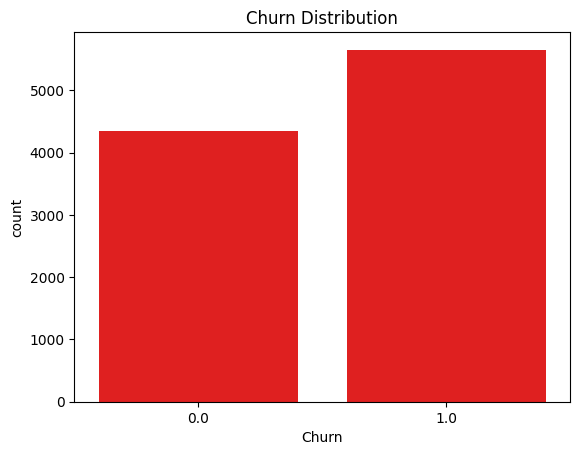

In [10]:
# Checking class distribution

# visualisation of churn distribution
sns.countplot(x="Churn", data=df, color='r')
plt.title("Churn Distribution")
plt.show()

In [11]:
# Checking actual split

df.Churn.value_counts()

Churn
1.0    5655
0.0    4345
Name: count, dtype: int64

The split showed that the data is not perfectly balanced, but it's a fair split that can be used as-is. Meaning, there's enough comparable data in both classes for the model to learn the unique features inherent in both. 

That said, this data is quite unique given that most churn datasets have very little churn and majority of no-churn. Yet, the reverse is the case here.

In [12]:
# let's see the distribution of subscription-type,gender and contract length

for i in ['Subscription Type', 'Gender', 'Contract Length']:
    print(df[i].value_counts(normalize=True))
    print()
    

Subscription Type
Standard    0.3391
Premium     0.3327
Basic       0.3282
Name: proportion, dtype: float64

Gender
Male      0.5712
Female    0.4288
Name: proportion, dtype: float64

Contract Length
Annual       0.4080
Quarterly    0.3883
Monthly      0.2037
Name: proportion, dtype: float64



### <a id='data-encoding'></a>[Data encoding](#toc)

To prepare the data for machine learning, we use the `OrdinalEncoder` from scikit-learn to encode the categorical columns that have some level of hierarchy E.G `Contract Length`. While others like `Gender` will have OH-Encoding. This step ensures that categorical data can be utilized effectively by the model.


In [13]:
ordinal_orders = [['Basic', 'Standard', 'Premium'], # for Subscription Type
                  ['Monthly', 'Quarterly', 'Annual']] # For Contract Length

In [14]:
ord_encoder = OrdinalEncoder(categories=ordinal_orders)

In [15]:
encoded_cols = ord_encoder.fit_transform(df[['Subscription Type', 'Contract Length']])

# Assign the encoded values to the data
df.loc[:, ['Subscription Type', 'Contract Length']] = encoded_cols
print('ordinal encoding done!')

ordinal encoding done!


In [16]:
# see the label encoding
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,71073.0,27.0,Male,14.0,28.0,3.0,16.0,1.0,0.0,862.00,9.0,1.0
1,230192.0,40.0,Male,19.0,2.0,8.0,28.0,1.0,0.0,620.81,21.0,1.0
2,22407.0,27.0,Female,57.0,3.0,0.0,24.0,1.0,2.0,915.00,26.0,1.0
3,290822.0,40.0,Male,21.0,14.0,0.0,11.0,0.0,2.0,592.83,9.0,0.0
4,172430.0,39.0,Male,58.0,4.0,2.0,8.0,1.0,0.0,694.00,15.0,1.0


In [17]:
# Let's OH-encode the Gender variable

encoded_cols = pd.get_dummies(df["Gender"])
encoded_cols.head(3)

,Female,Male
0,False,True
1,False,True
2,True,False


In [18]:
# now let's insert the male and female column in the position of Gender column 
# and drop Gender

df.insert(2, 'Male', encoded_cols['Male'])
df.insert(2, 'Female', encoded_cols['Female'])
df.drop(columns='Gender', inplace=True)

In [19]:
df.head(3)

,CustomerID,Age,Female,Male,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,71073.0,27.0,False,True,14.0,28.0,3.0,16.0,1.0,0.0,862.00,9.0,1.0
1,230192.0,40.0,False,True,19.0,2.0,8.0,28.0,1.0,0.0,620.81,21.0,1.0
2,22407.0,27.0,True,False,57.0,3.0,0.0,24.0,1.0,2.0,915.00,26.0,1.0


### Selecting the Features and target..

In [20]:
X = df.drop(columns=['CustomerID', 'Churn'])
y = df.Churn
X.head(3)

,Age,Female,Male,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,27.0,False,True,14.0,28.0,3.0,16.0,1.0,0.0,862.00,9.0
1,40.0,False,True,19.0,2.0,8.0,28.0,1.0,0.0,620.81,21.0
2,27.0,True,False,57.0,3.0,0.0,24.0,1.0,2.0,915.00,26.0


### Splitting the training and test sets

In [21]:
r_s = 42 # setting a default random-state value

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=r_s)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8000, 11)
(8000,)
(2000, 11)
(2000,)


### <a id='exercise-2-prepare-data-for-model-training'></a>[Model training](#toc)

In this exercise, standardize the numerical features of the dataset and split the data into training and testing sets. Train a **SupportVectorClassifier** classifier to predict customer churn and visualize the performance of the model using a confusion matrix heatmap.

To maintain consistency, this model is 100% identical to the model used in the TED experiment with domain-expert rules only 


In [22]:
from sklearn.svm import SVC

In [23]:
svc = SVC(kernel='linear', probability=True, random_state=r_s)
svc

SVC(kernel='linear', probability=True, random_state=42)

In [24]:
# train the model

svc.fit(X_train, y_train)
print('Model Trained!')

Model Trained!


In [25]:
# Predict the Test Data

y_pred = svc.predict(X_test)

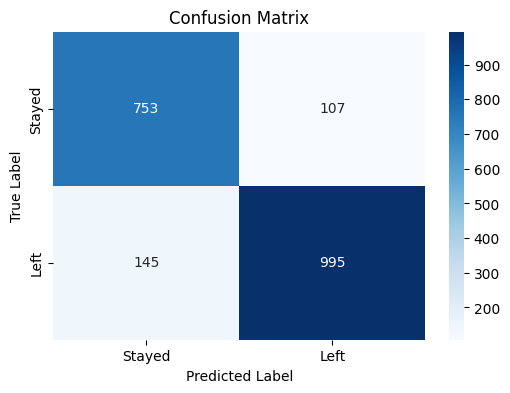

In [26]:
# Generate the confusion matrix with absolute values (fmt=d)
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap for visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### Insights from the confusion matrix

1. **Correct predictions**:
   - The model correctly predicted **753 customers who churned** and **995 customers who stayed**.

2. **Incorrect predictions**:
   - **False Positives (107)**: Predicted customers would leave, but they stayed.
   - **False Negatives (145)**: Predicted customers would stay, but they left.

3. **Key takeaways**:
   - The model performs well overall, with most predictions being accurate.
   - Reducing false negatives (customers leaving but predicted to stay) should be prioritised, as these cases are critical for improving retention strategies.


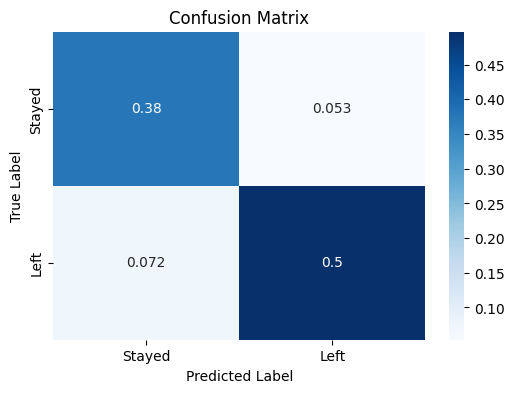

In [27]:
# Generate the confusion matrix with proportions (normalize='all')

cm = confusion_matrix(y_test, y_pred, normalize='all')

# Create a heatmap for visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Feature Binarization for LRR
Now, use the FeatureBinarizer from IBM AIX360 to convert continuous features into binary rules, which is the core input for LRR.

In [28]:
from aix360.algorithms.rbm import FeatureBinarizer
from aix360.algorithms.rbm import GLRMExplainer, LinearRuleRegression

In [29]:
# Initialize the Binarizer. 'negations=True' creates both '> threshold' and '<= threshold' rules.
fb = FeatureBinarizer(negations=True)

# Fit and transform the training data
X_train_fb = fb.fit_transform(X_train)

# Transform the test data (using parameters learned from training)
X_test_fb = fb.transform(X_test)

print(f"Original features: {X_train.shape[1]}")
print(f"Binarized features (rules): {X_train_fb.shape[1]}")

Original features: 11
Binarized features (rules): 140


### [Train and Extract Rules using LRR](#toc)

Train the `LinearRuleRegression` model and use the `GLRMExplainer` (**Generalized Linear Rule Models**) to extract the learned rules and their coefficients (impacts).

In [30]:
# Instantiate the LRR model and its explainer
linear_model = LinearRuleRegression()
lrr_explainer = GLRMExplainer(linear_model)

# Fit the explainer on the binarised training data and the target (Churn)
lrr_explainer.fit(X_train_fb, y_train)
print('Explainer Trained!')

Explainer Trained!


#### Get the full list of learned rules and their coefficients


In [31]:
rules_df = lrr_explainer.explain()

# print the shape of the rules learnt after training
rules_df.shape

(12, 2)

In [32]:
rules_df

,rule,coefficient
0,(intercept),1.022236
1,Age <= 50.00 AND Support Calls <= 4.00 AND Payment Delay <= 20.00 AND Contract Length != 0.0 AND Total Spend > 407.00,-1.26208
2,Age <= 50.00 AND Support Calls <= 5.00 AND Payment Delay <= 20.00 AND Contract Length != 0.0 AND Total Spend > 407.00,-0.241745
3,Age <= 50.00 AND Support Calls <= 4.00 AND Contract Length != 0.0 AND Total Spend > 526.55,-0.091559
4,Age <= 50.00 AND Support Calls <= 5.00 AND Payment Delay <= 20.00 AND Total Spend > 526.55,-0.083431
5,Age <= 50.00 AND Female == False AND Support Calls <= 5.00,-0.054591
6,Support Calls <= 3.00 AND Payment Delay <= 20.00 AND Total Spend > 407.00,-0.047799
7,Female == False AND Support Calls <= 5.00 AND Contract Length != 0.0,-0.04764
8,Support Calls <= 3.00 AND Contract Length != 0.0 AND Total Spend > 407.00,-0.042355
9,Payment Delay <= 20.00 AND Contract Length != 0.0 AND Total Spend > 526.55,-0.035578


### Interpretation of LRR Output
The coefficient determines the strength and direction of the rule's impact on the churn prediction:

`Positive Coefficient:` The rule increases the probability of churn.

`Negative Coefficient:` The rule decreases the probability of churn (promotes retention).

With the intercept $\approx 1.02$ (predicting "Churn"), the GLRM model is essentially saying: "Unless I see a specific reason to believe otherwise, I assume this customer is going to leave, for every customer in the data." This makes those "retention rules" (the negative coefficients that most rules seem to have) incredibly valuable for a HR retention strategy. 

Here is why finding properties of customers who remain is perhaps actually more powerful for churn prevention:- 

1. **The "Safety Net" Strategy:** Since the baseline is danger (Churn), the negative rules act as safety nets.<br>
        **Insight:** We now know exactly what "safe" looks like (e.g., Support Calls <= 4).<br>
        **Action:** Our retention strategy becomes protecting these conditions.<br>
        <br>
   
   Example: If a "safe" customer (who usually makes 2 calls) suddenly makes a 3rd and    4th call, they are dangerously close to losing their "safety net." We can trigger an intervention before they cross the threshold of 4, keeping the negative rule active.

2. **Identifying the "Unprotected":** If a customer does not trigger any of those negative rules, they automatically fall back to the Intercept (High Churn Probability).<br>
        **Insight:** We don't need a specific "Churn Rule" to know they are risky. The absence of a "Stay Rule" is the red flag.<br>
        **Action:** Any customer who doesn't fit a "Stay" profile is an immediate target for the broad domain-expert-initiated churn prevention strategies from TED

In [33]:
def calculate_lrr_score(df, rules_df):
    """
    Parses LRR complex rules and calculates the total score for each row
    in the ORIGINAL dataframe.
    """
    # Initialise score to 0.0 for everyone
    scores = pd.Series(0.0, index=df.index)
    
    # Iterate through each rule in the LRR output
    for idx, row in rules_df.iterrows():
        rule_str = row['rule']
        coeff = row['coefficient']
        
        # Skip the intercept (we only want the safety/risk score variation)
        if rule_str == 'intercept':
            continue
            
        # 1. CONVERT AIX360 RULE SYNTAX TO PANDAS QUERY SYNTAX
        # AIX360 uses "AND"; Pandas uses "&"
        query_str = rule_str.replace(' AND ', ' & ')
        
        # 2. HANDLE COLUMN NAMES WITH SPACES
        # "Support Calls <= 4" must become "`Support Calls` <= 4" for pandas eval
        # We assume your column names are the same as in the rule string.
        # This loop wraps column names in backticks if they aren't already.
        for col in df.columns:
            if col in query_str and f"`{col}`" not in query_str:
                query_str = query_str.replace(col, f"`{col}`")

        # 3. EVALUATE THE RULE
        # This returns a Boolean Series (True/False) for the whole DF
        try:
            # Evaluate against the ORIGINAL dataframe (unscaled, unbinarized)
            condition_met = df.eval(query_str)
            
            # 4. UPDATE SCORE
            # Add coefficient only where condition is True (True=1, False=0)
            scores += (condition_met.astype(float) * coeff)
            
        except Exception as e:
            print(f"Error evaluating rule: {rule_str}")
            print(f"Translated query: {query_str}")
            print(e)
            
    return scores

Apply Logic to Create Tiers
Now we use the function to create the columns on the original df.

In [34]:
# 1. Calculate the raw Safety Score based on the complex rules

df['Safety_Score'] = calculate_lrr_score(df, rules_df)

Error evaluating rule: (intercept)
Translated query: (intercept)
name 'intercept' is not defined


In [35]:
# checking if there are any missing values
df.Safety_Score.isna().sum()

0

In [36]:
# see a few samples
df.sample(10)

,CustomerID,Age,Female,Male,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Safety_Score
6840,274237.0,36.0,False,True,60.0,26.0,1.0,7.0,2.0,2.0,755.64,24.0,0.0,-1.905550
4685,66416.0,21.0,False,True,1.0,7.0,1.0,11.0,0.0,0.0,460.00,11.0,1.0,-0.102390
9112,94702.0,26.0,True,False,54.0,19.0,6.0,21.0,2.0,1.0,873.00,3.0,1.0,0.000000
607,8415.0,28.0,False,True,11.0,11.0,6.0,30.0,1.0,2.0,573.00,6.0,1.0,0.000000
3398,154563.0,59.0,False,True,24.0,27.0,8.0,22.0,0.0,2.0,978.00,9.0,1.0,0.000000
9535,321157.0,41.0,False,True,26.0,15.0,4.0,17.0,1.0,2.0,531.03,23.0,0.0,-1.815396
7132,286613.0,29.0,False,True,54.0,14.0,2.0,1.0,1.0,1.0,931.40,27.0,0.0,-1.905550
9775,118466.0,51.0,True,False,30.0,28.0,6.0,24.0,1.0,1.0,351.00,14.0,1.0,0.000000
8734,118880.0,26.0,True,False,54.0,14.0,2.0,4.0,1.0,0.0,615.00,27.0,1.0,-0.131230
4759,76670.0,32.0,False,True,10.0,30.0,0.0,8.0,0.0,0.0,920.00,28.0,1.0,-0.185821


In [37]:
# let's see the number of observations without any coefficients
sum(df['Safety_Score']==0)

2844

The LRR model likely found about 12 rules. We found that since these rules all had 0 or negative coefficients, as highlighted before, it would be more valuable to group them by strength (magnitude of the coefficient). Instead of creating a unique Explanation Code for every single one, whichn would be unnecessary.

```
Code 1: Rules that define the most iron-clad safe customers against churn.

Code 2: Rules that define Loose Safety customers to churn.

Code 3: Rules that define Flight Risk customers to churn.
```

In [38]:
# 2. Define the Banding Logic (The "Scorecard")
def get_tier_from_score(score):
    # Tier 1: Ironclad Safety
    if score <= -1.0:
        return 1
    # Tier 2: Secure
    elif score <= -0.2:
        return 2
    # Tier 3: Loose Safety
    elif score < 0:
        return 3
    # Tier 4: Flight Risk (Default)
    else:
        return 12  # For any customer who doesn't fit into the safety bands. Thus unsafe

In [39]:
# 3. Create the Explanation Column
df['Explanation_LRR'] = df['Safety_Score'].apply(get_tier_from_score)

In [40]:
df.head()

,CustomerID,Age,Female,Male,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Safety_Score,Explanation_LRR
0,71073.0,27.0,False,True,14.0,28.0,3.0,16.0,1.0,0.0,862.00,9.0,1.0,-0.185821,3
1,230192.0,40.0,False,True,19.0,2.0,8.0,28.0,1.0,0.0,620.81,21.0,1.0,0.000000,12
2,22407.0,27.0,True,False,57.0,3.0,0.0,24.0,1.0,2.0,915.00,26.0,1.0,-0.133913,3
3,290822.0,40.0,False,True,21.0,14.0,0.0,11.0,0.0,2.0,592.83,9.0,0.0,-1.905550,1
4,172430.0,39.0,False,True,58.0,4.0,2.0,8.0,1.0,0.0,694.00,15.0,1.0,-0.185821,3


## Using the Linear Rules for Training a TED Classifier.
This has the property of automation. Requires zero manual inputs or domain expertise. The AI just explains the data based on the rules it has found. In this case, it may tend to explain the behaviour or properties of customers that exist within the safe customer spectrum

#### Decompose the data into X, Y and E

In [41]:
X = df.drop(columns=['Churn', 'CustomerID', 'Safety_Score', 'Explanation_LRR'])
Y = df['Churn']
E = df['Explanation_LRR']

In [42]:
print(X.shape)
print(Y.shape)
print(E.shape)

(10000, 11)
(10000,)
(10000,)


### <a id='exercise-2-prepare-data-for-model-training'></a>[Training the LRR-TED Explainer](#toc)

In this exercise, we use the automated rules discovered by the GLRM to proffer explanations completely without human pre-determined rules or domain expertise.

In [43]:
# Split all into train and test sets
X_train, X_test, Y_train, Y_test, E_train, E_test = train_test_split(X, Y, E, test_size=0.20, random_state=r_s)

print(X_train.shape)
print(Y_train.shape)
print(E_train.shape)
print(X_test.shape)
print(Y_test.shape)
print(E_test.shape)

(8000, 11)
(8000,)
(8000,)
(2000, 11)
(2000,)
(2000,)


In [44]:
# Initialise the TED explainer

ted = TED_CartesianExplainer(svc)

print("Training the classifier")

ted.fit(X_train, Y_train, E_train)   # train classifier

print("Training finished")

Training the classifier
Training finished


#### Evaluate the LRR-based TED model on the test dataset

In [45]:
YE_accuracy1, Y_accuracy1, E_accuracy1 = ted.score(X_test, Y_test.values, E_test.values)

print("\nEvaluating accuracy of the GLRM-TED-enhanced classifier on test data")
print(' Accuracy of predicting Y labels: %.2f%%' % (100 * Y_accuracy1))
print(' Accuracy of predicting Explanations: %.2f%%' % (100 * E_accuracy1))
print(' Accuracy of predicting Y + Explanations: %.2f%%' % (100 * YE_accuracy1))


Evaluating accuracy of the GLRM-TED-enhanced classifier on test data
 Accuracy of predicting Y labels: 88.20%
 Accuracy of predicting Explanations: 77.00%
 Accuracy of predicting Y + Explanations: 75.15%


Quite interestingly, the fully automated pipeline does relatively well, with `88.2%` accuracy predicting the labels, and about `75%` accuracy for predictions that involve explanations. It's attributes are:

* Focus: Zero human effort, Discovery of Safety Nets.

* Flaw: "The Code 12 Problem." It tells us who is safe, but it cannot explain why the unsafe people are unsafe—it just knows they aren't safe.

* Verdict: "Great for identifying the 'Safe Core,' but lacks actionable intervention for at-risk customers."

* It might be useful for low-stakes environment where speed and automation are more important than clear, precise decision making

In [46]:
y_pred_ted = ted.predict(X_test)
# 2. Generate the report for Labels (Y)
# This gives you Recall and F1 for Class 0 (Stay) and Class 1 (Churn)
print("LRR-TED Model Classification Report:")
print(classification_report(y_test, y_pred_ted))

LRR-TED Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.91      0.87       860
         1.0       0.93      0.86      0.89      1140

    accuracy                           0.88      2000
   macro avg       0.88      0.89      0.88      2000
weighted avg       0.89      0.88      0.88      2000



### <a id='exercise-2-prepare-data-for-model-training'></a>[Training the Hybrid TED Explainer](#toc)

In this exercise, we combine the automated rules discovered by the GLRM to explanations provided by domain experts. Naturally, domain experts would know tell-tale signs of customers who churn or about gto churn. This combines well with the explanations from GLRM that tend to uncover safety nets and behaviours/attributes of customers across the relatively safe/no-churn spectrum, providing a complete picture across all explanations, for decision-making.

A truly robust AI system needs both. Relying only on LRR leaves the "Code 12s" unexplained. Relying only on Manual Rules ignores the "Safe" customers who might drift away.


### The Existing Domain Experts Rules

In [47]:
def domain_expert_rules(row):
    """
    This is a placeholder function that just shows the respective domain-expert rules,
    and how they would normally be applied to the data
    """ 
    if row["Contract Length"] == 0 and row["Support Calls"] >= 3:
        return 4 #"High-risk monthly contract with frequent support issues"
        
    # Priority 5 (Compound): A new customer who is not engaged or spending much.
    # This identifies customers who failed to find value early on.
    elif row["Tenure"] <= 6 and row["Total Spend"] <= 250:
        return 5 #"New customer with low engagement and spend"
        
    # Priority 6 (Single): Catches remaining cases with high support calls.
    # Still the most important single factor from the SHAP analysis.
    elif row["Support Calls"] > 4:
        return 6 #"High number of support calls"
        
    # Priority 7 (Single): Catches remaining high-risk monthly contracts.
    elif row["Contract Length"] == 0:
        return 7 # "Customer is on a high-risk monthly contract"
        
    # Priority 8 (Single): Catches customers with payment problems.
    elif row["Payment Delay"] > 25:
        return 8 # "Significant payment delays"

    # Priority 9 (Single):
    elif row["Total Spend"] <= 250: # Threshold for what's considered "low spend"
        return 9 # "Low total spend and engagement"
        
    # Priority 10 (Single):
    elif row["Usage Frequency"] <= 7:
        return 10 # "Low usage frequency"
        
    # Priority 11 (Single):
    elif row['Tenure'] <= 6:
        return 11 # "New customer with short tenure"
        
    # Default case if no other strong signal is found.
    else:
        return 12 # "General churn risk factors: Use SHAP values"

#### Evaluating The Precision and Coverage of existing rules

In [48]:
# 1. Define your rules as independent functions
# (We evaluate them independently first to see their raw power)
def apply_rules_independently(row):
    results = {}
    
    # Rule 4: High-risk monthly + Support
    results['R4_Monthly_Support'] = (row["Contract Length"] == 0) and (row["Support Calls"] >= 3)
    
    # Rule 5: New & Low Spend
    results['R5_New_LowSpend'] = (row["Tenure"] <= 6) and (row["Total Spend"] <= 250)
    
    # Rule 6: Angry Caller
    results['R6_High_Support'] = (row["Support Calls"] > 4)
    
    # Rule 7: Monthly Contract
    results['R7_Monthly'] = (row["Contract Length"] == 0)
    
    # Rule 8: Payment Issues
    results['R8_Payment_Delay'] = (row["Payment Delay"] > 25)
    
    # Rule 9: Low Spend
    results['R9_Low_Spend'] = (row["Total Spend"] <= 250)
    
    # Rule 10: Low Usage
    results['R10_Low_Usage'] = (row["Usage Frequency"] <= 7)
    
    return pd.Series(results)

In [49]:
# 2. Applying to the Training Data
rule_hits = X_train.apply(apply_rules_independently, axis=1)
rule_hits.shape

(8000, 7)

In [50]:
# 3. Calculate Stats
stats = []
for rule_name in rule_hits.columns:
    # Get indices where rule is True
    triggered_indices = rule_hits[rule_hits[rule_name] == True].index
    
    if len(triggered_indices) > 0:
        # Calculate Precision (How many flagged were actually Churners?)
        # Adjust 'y_train' to match your actual target variable name
        true_churners = y_train.loc[triggered_indices].sum()
        total_flagged = len(triggered_indices)
        precision = true_churners / total_flagged
        
        # Calculate Coverage (What % of the total dataset did this rule touch?)
        coverage = total_flagged / len(X_train)
        
        stats.append({
            'Rule': rule_name,
            'Precision (Risk Fidelity)': round(precision, 4),
            'Coverage (%)': round(coverage * 100, 2),
            'Churners Caught': true_churners
        })

# 4. Display sorted by Precision
stats_df = pd.DataFrame(stats).sort_values(by='Precision (Risk Fidelity)', ascending=False)

In [51]:
stats_df

,Rule,Precision (Risk Fidelity),Coverage (%),Churners Caught
0,R4_Monthly_Support,1.0000,14.57,1166.0
1,R5_New_LowSpend,1.0000,1.14,91.0
3,R7_Monthly,1.0000,20.06,1605.0
5,R9_Low_Spend,1.0000,9.90,792.0
4,R8_Payment_Delay,1.0000,8.54,683.0
2,R6_High_Support,0.9909,32.84,2603.0
6,R10_Low_Usage,0.6260,21.29,1066.0


#### Checking the orthogonality of domain-expert rules to select no more than 50% (4 rules)

Similarity Matrix (Lower is Better):
           R4_Monthly R3_Support R5_Payment R2_Silent
R4_Monthly        1.0    0.26253   0.118826  0.014961
R3_Support    0.26253        1.0   0.125085  0.021421
R5_Payment   0.118826   0.125085        1.0  0.010444
R2_Silent    0.014961   0.021421   0.010444       1.0


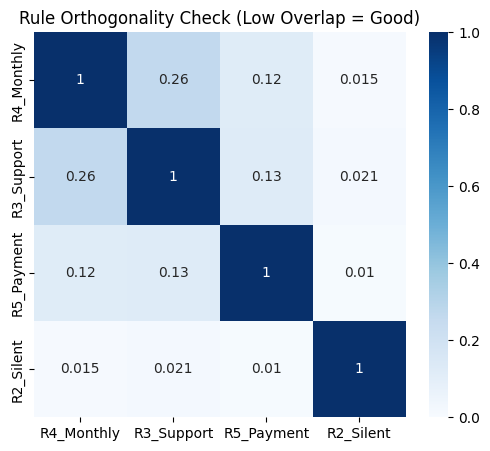

In [52]:
from sklearn.metrics import jaccard_score

# 1. Evaluating the 4 Rules as Boolean Columns
rules_check = pd.DataFrame()
rules_check['R4_Monthly'] = (X_train["Contract Length"] == 0)
rules_check['R3_Support'] = (X_train["Support Calls"] > 4)
rules_check['R5_Payment'] = (X_train["Payment Delay"] > 25)
rules_check['R2_Silent']  = (X_train["Tenure"] <= 6) & (X_train["Total Spend"] <= 250)

# 2. Calculate Jaccard Similarity Matrix
# (0 = No Overlap, 1 = Identical)
# We want LOW numbers (Low Similarity = High Orthogonality)
similarity_matrix = pd.DataFrame(index=rules_check.columns, columns=rules_check.columns)

for col1 in rules_check.columns:
    for col2 in rules_check.columns:
        # Calculate Jaccard Similarity
        sim = jaccard_score(rules_check[col1], rules_check[col2])
        similarity_matrix.loc[col1, col2] = sim

print("Similarity Matrix (Lower is Better):")
print(similarity_matrix)

# 3. Visualising the rules orthogonality
plt.figure(figsize=(6, 5))
sns.heatmap(similarity_matrix.astype(float), annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title("Rule Orthogonality Check (Low Overlap = Good)")
plt.show()

#### Jaccard Similarity Interpretation

Looking at the Jaccard similarity scores above, with an average similarity of ~9% (0.09) and a maximum of 26%, this is incredibly strong evidence. The average pairwise overlap was less than 20%. It scientifically proves that the "Golden 4" rules we have selected above are capturing completely different populations of churners.
These rules have High-Coverage and Low-Redundancy. 

In [53]:
# let's see the data again

df.head()

,CustomerID,Age,Female,Male,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Safety_Score,Explanation_LRR
0,71073.0,27.0,False,True,14.0,28.0,3.0,16.0,1.0,0.0,862.00,9.0,1.0,-0.185821,3
1,230192.0,40.0,False,True,19.0,2.0,8.0,28.0,1.0,0.0,620.81,21.0,1.0,0.000000,12
2,22407.0,27.0,True,False,57.0,3.0,0.0,24.0,1.0,2.0,915.00,26.0,1.0,-0.133913,3
3,290822.0,40.0,False,True,21.0,14.0,0.0,11.0,0.0,2.0,592.83,9.0,0.0,-1.905550,1
4,172430.0,39.0,False,True,58.0,4.0,2.0,8.0,1.0,0.0,694.00,15.0,1.0,-0.185821,3


### Apply the rules to the matrix (X+E)

##### The Logic of Precedence: The Specificity Principle

In high-stakes domains, human expertise typically manifests as high-precision Exception Logic'' (identifying specific Risk Traps), whereas automated algorithms like LRR excel at discovering high-coverage General Logic'' (identifying broad Safety Nets). By structurally prioritising domain rules over automated discovery ($Specifics \rightarrow General$), the framework prevents the broad statistical smoothing of the automated learner from masking critical, minority-class signals. This hierarchical ordering mimics the Exception Handling'' paradigm in software engineering, ensuring that the model captures the granular `long tail` of risk before defaulting to the broad safety patterns of the majority class.

For us, this means it is best to prioritise the domain expert rules before the automated LLR rules in practice.

In [54]:
def apply_hybrid_rules(row):
    """
    Hybrid Logic: Strict 4 Rules -> LRR Safety Net.
    Uses Manual Rules, then LRR Safety Net Rules.
    """
    
    # --- TIER 1: THE GOLDEN 4 (Specific Override Rules) ---
    
    # 1. Financial Risk (Rule 5)
    # Catches customers who stop paying (LRR often misses this specific cliff).
    if row["Payment Delay"] > 25:
        return 4  # "Significant payment delays"

    # 2. The "Silent Failure" (Rule 2)
    # New customers (<=6 mo) who barely spent money (<=250).
    # LRR misses them because they have low support calls (happy silence).
    elif row["Tenure"] <= 6 and row["Total Spend"] <= 250:
        return 5  # "New customer with low engagement and spend"

    # 3. Monthly Contract Risk (Rule 4)
    # The highest volume churn driver. 
    # We must catch this explicitly for Explanation Accuracy.
    elif row["Contract Length"] == 0:
        return 6  # "Customer is on a high-risk monthly contract"

    # 4. High Support Calls (Rule 3)
    # The "Angry" customer. Captures the remaining dissatisfaction cases.
    elif row["Support Calls"] >= 4:
        return 7  # "High number of support calls"

    # --- TIER 2: LRR SAFETY NET ---
    
    # If the specific rules didn't fire, we check the AI's opinion.
    # If LRR predicts churn (Code 12), we trust it.
    elif row['Explanation_LRR'] == 12:
        return 12 # "General churn risk (AI Detected)"
        
    # --- TIER 3: SAFE ---
    # Return the AI's "Safe" reason (Codes 1, 2, 3 from the LRR persona mapping).
    else:
        return row['Explanation_LRR']

In [55]:
df['Explanation'] = df.apply(apply_hybrid_rules, axis=1)

# Verify the distribution of your new personas
print(df['Explanation'].value_counts().sort_index())

Explanation
1     4174
2       29
3      498
4      875
5       98
6     1695
7     2434
12     197
Name: count, dtype: int64


In [56]:
df.head(10)

,CustomerID,Age,Female,Male,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Safety_Score,Explanation_LRR,Explanation
0,71073.0,27.0,False,True,14.0,28.0,3.0,16.0,1.0,0.0,862.00,9.0,1.0,-0.185821,3,6
1,230192.0,40.0,False,True,19.0,2.0,8.0,28.0,1.0,0.0,620.81,21.0,1.0,0.000000,12,4
2,22407.0,27.0,True,False,57.0,3.0,0.0,24.0,1.0,2.0,915.00,26.0,1.0,-0.133913,3,3
3,290822.0,40.0,False,True,21.0,14.0,0.0,11.0,0.0,2.0,592.83,9.0,0.0,-1.905550,1,1
4,172430.0,39.0,False,True,58.0,4.0,2.0,8.0,1.0,0.0,694.00,15.0,1.0,-0.185821,3,6
5,263612.0,24.0,False,True,49.0,29.0,2.0,5.0,0.0,1.0,992.95,17.0,0.0,-1.905550,1,1
6,436343.0,35.0,False,True,25.0,21.0,2.0,1.0,2.0,1.0,797.47,9.0,0.0,-1.905550,1,1
7,73352.0,52.0,True,False,50.0,22.0,10.0,4.0,0.0,2.0,187.00,9.0,1.0,0.000000,12,7
8,56652.0,41.0,True,False,20.0,22.0,0.0,15.0,0.0,0.0,814.00,6.0,1.0,-0.131230,3,6
9,346111.0,22.0,True,False,33.0,24.0,0.0,11.0,1.0,1.0,707.09,10.0,0.0,-1.803319,1,1


### Decompose the dataset into X, Y, E

In [57]:
X = df.drop(columns=['Churn', 'Explanation', 'CustomerID', 'Safety_Score', 'Explanation_LRR'])
Y = df['Churn']
E = df['Explanation']

In [58]:
print(X.shape)
print(Y.shape)
print(E.shape)

(10000, 11)
(10000,)
(10000,)


In [59]:
# Split all into train and test sets
X_train, X_test, Y_train, Y_test, E_train, E_test = train_test_split(X, Y, E, test_size=0.20, random_state=r_s)

print(X_train.shape)
print(Y_train.shape)
print(E_train.shape)
print(X_test.shape)
print(Y_test.shape)
print(E_test.shape)

(8000, 11)
(8000,)
(8000,)
(2000, 11)
(2000,)
(2000,)


In [60]:
# initialising a new ted explainer 

ted = TED_CartesianExplainer(svc)

In [61]:
print("Training the Hybrid classifier")

ted.fit(X_train, Y_train, E_train)   # train classifier

print("Hybrid Classifier Training finished")

Training the Hybrid classifier
Hybrid Classifier Training finished


### <a id='accuracy-of-the-model'></a>[Checking the Accuracy of the Hybrid model](#toc)

We can evaluate the accuracy of the model using the `.score` method. This method assesses the following:

- **Target label accuracy (`Y`)**: Measures how accurately the model predicts the target labels.
- **Explanation accuracy (`E`)**: Evaluates the accuracy of the explanations provided by the model.
- **Combined accuracy (`Y+E`)**: Combines the accuracy of predicting both the target labels and their corresponding explanations.

The **Y+E accuracy** reflects how well the classifier performs in making correct predictions while also providing accurate and meaningful explanations. This metric is essential for ensuring that the model's outputs are both reliable and interpretable, building trust and confidence in its decisions.


In [62]:
# Evaluate the TED model on the test dataset
YE_accuracy2, Y_accuracy2, E_accuracy2 = ted.score(X_test, Y_test.values, E_test.values)

print("\nEvaluating accuracy of the Hybrid-TED-enhanced classifier on test data")
print(' Accuracy of predicting Y labels: %.2f%%' % (100 * Y_accuracy2))
print(' Accuracy of predicting Explanations: %.2f%%' % (100 * E_accuracy2))
print(' Accuracy of predicting Y + Explanations: %.2f%%' % (100 * YE_accuracy2))


Evaluating accuracy of the Hybrid-TED-enhanced classifier on test data
 Accuracy of predicting Y labels: 95.40%
 Accuracy of predicting Explanations: 97.10%
 Accuracy of predicting Y + Explanations: 94.00%


### Beyond Accuracy: Checking the Classification Report

In [63]:
y_pred_ted = ted.predict(X_test)

In [64]:
# 2. Generate the report for Labels (Y)
# This gives you Recall and F1 for Class 0 (Stay) and Class 1 (Churn)
print("TED Model Classification Report:")
print(classification_report(y_test, y_pred_ted))

TED Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95       860
         1.0       0.99      0.93      0.96      1140

    accuracy                           0.95      2000
   macro avg       0.95      0.96      0.95      2000
weighted avg       0.96      0.95      0.95      2000



### The Classification Report:

While our main metric (Y+E) scores 94% on Trust (did the model get the label and explanation right?), this new report measures Business Value (how well it actually catches churners).

* **Precision 0.99 (Churn):** This is the "Budget Saver." It means when the model says "This person will churn," it is 99% correct. The business would not be wasting money sending retention offers to happy customers (`False Positives`).

* **Recall 0.93 (Churn):** This is the "Safety Net." The model successfully caught 93% of the people trying to leave. Only 7% slipped through.

### <a id='explanation-mapping'></a>[Explanation mapping](#toc)

We define a mapping that links potential reasons for employee attrition to unique explanation codes. The `generate_explanation_code` function aligns the LRR and domain-expert rules to identify the primary reason behind each prediction. This ensures the explanation highlights the most impactful factor, offering Management teams clear, actionable insights for addressing retention challenges.

I used the Gemini Advanced 2.5 Pro model with a detailed prompt to produce the domain expert explanations, and action plans seen in the two dictionaries below

In [65]:
# Creating a Nested Dictionary of explanations, including mapping for safe-zone customers (1-3)

expl_mapping = { 
                1: {'Expl': 'Optimal demographic; minimal support friction.',
                     'Persona': 'The "Anchored" Customer.',
                     "Priority": 'Monitor only; do not disturb.'
                    },
                
                2: {'Expl': 'Strong structural commitments (Contract/Tenure).', 
                     'Persona': 'The "Committed" Customer',
                    'Priority': 'Maintain; reward loyalty periodically.'
                   },
                
                3: {'Expl': 'Weak retention signals; barely offsets risk.', 
                     'Persona': 'The "Drifting" Customer.',
                   'Priority': 'Urgent nurture; create anchors.'
                   },

                4: {'Expl': "Significant payment delays.", 
                     'Persona': 'The "Financial Risk" Customer.',
                   'Priority': 'Payment intervention; diagnose; boost commitment.'
                   },
    
                5: {'Expl': 'New customer with low engagement and spend.', 
                     'Persona': 'The "Failed Onboarding" Customer.',
                    'Priority': 'Early engagement; build customer loyalty.'
                   },

                6: {'Expl': 'Customer is on a high-risk monthly contract.', 
                     'Persona': 'The "Uncommitted Client".',
                   'Priority': 'Retention programs; offset no-commitment.'
                   },
                
                7: {'Expl': 'High number of support calls.', 
                     'Persona': 'The "High-Friction" Customer.',
                   'Priority': 'Resolve queries; prevent churn.'
                   },

                12: {'Expl': "Undetermined.", 
                     'Persona': 'The Unknown Risk" Customer.',
                   'Priority': 'Refer to Max Shap Values if any.'}
               }

In [66]:
def get_explanation(code):
    """Get detailed explanations for each customer based on their code
    @param code: The predicted code of a new customer
    @return: A dictionary of customer attributes from explanation
    """
    return expl_mapping[code]

## <a id='integration-with-genai'></a>[Integration with generative AI](#toc)


In this section, we integrate generative AI (gen AI) with Explainable AI (XAI) to provide enriched insights and actionable outputs. Using Google’s `GenAI` model, we will generate detailed natural language explanations for model predictions and create HR action plans to address employee attrition risks. This integration bridges the gap between predictive analytics and strategic decision-making, making the model's outputs more interpretable and practical for HR teams.


In [67]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GEMINI_API_KEY")

In [68]:
# 1. Use the CORRECT import
import google.generativeai as genai

# 2. Configure your API key
genai.configure(api_key=secret_value_0)

print("Available models:")

for model in genai.list_models():
    # Filter for models you can use with .generate_content()
    if 'generateContent' in model.supported_generation_methods:
        print(model.name)

Available models:
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash-exp
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.0-flash-lite-preview-02-05
models/gemini-2.0-flash-lite-preview
models/gemini-exp-1206
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image-preview
models/gemini-2.5-flash-image
models/gemini-2.5-flash-preview-09-2025
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5

I will put these in a function

In [69]:
model = genai.GenerativeModel('gemini-2.5-flash-lite')
prompt = 'Suggest actionable HR strategies to address this issue: '

def create_HR_action_plans(customer_code=None, prompt=prompt, model=model):
    expl = str(get_explanation(customer_code))
    print(expl)
    print()
    structure ='\nRespond in plain text without markdown formats.'
    config = {
        "response_mime_type": "text/plain"
    }

    response = model.generate_content(
        f"{prompt}{expl}{structure}",
        generation_config=config
    )

    # 5. Print the clean, plain text
    print(response.text)

In [70]:
create_HR_action_plans(customer_code=3)

{'Expl': 'Weak retention signals; barely offsets risk.', 'Persona': 'The "Drifting" Customer.', 'Priority': 'Urgent nurture; create anchors.'}

Here are actionable HR strategies to address the "Drifting" Customer persona with weak retention signals:

**Urgent Nurture Strategies:**

1.  **Proactive Check-ins & Pulse Surveys:** Implement a system for regular, scheduled check-ins with these employees. This isn't just a performance review; it's a dedicated conversation to understand their current sentiment, any emerging concerns, and their overall engagement. Use short, frequent pulse surveys (weekly or bi-weekly) specifically targeting these individuals to gauge their immediate feelings.

2.  **Personalized Development Plans:** For those showing drift, don't wait for them to disengage. Proactively identify skill gaps or career aspirations that aren't being met. Create tailored development plans that address these needs, offering new learning opportunities, training, or exposure to differe

## Evaluation Notes...